# Common stuff
### based on QCD on the Lattice Ch. 3.3

In [840]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
#import tools
from scipy.optimize import curve_fit


# Wilson Loop
### based on ch. 3.4 and 3.5

In [841]:
#with h5py.File("../../h5/HotMultiPlaq.h5", "r") as f:
 #   f.visit(print)

In [842]:
# dimensionen machen murks..
def bootstrap(iterations, data):

    n = data.shape[0]

    indices = np.random.randint(0, n, size=(iterations, n))
    boot_samples = data[indices]       

    boot_means = np.mean(boot_samples, axis=1) 

    mean = np.mean(boot_means, axis=0)
    std  = np.std(boot_means, axis=0)

    return mean, std

In [843]:
def read_wilson_loops(filename, B, path = "Configuration", data_name = "loops"):

    all_data = []

    with h5py.File(filename, "r") as f:

        config_keys = list(f[path].keys())

        for cfg in config_keys: 

            T_keys = list(f[f"{path}/{cfg}"].keys())
            cfg_data = []

            for T in T_keys:

                data = f[f"{path}/{cfg}/{T}/{data_name}"][:]
                cfg_data.append(data)

            all_data.append(cfg_data)

    all_data = np.array(all_data)
    means = []
    stds = []

    for r in range(all_data.shape[2]):

        means_r = []
        stds_r = []

        for nt in range(all_data.shape[1]):

            data = all_data[:, nt, r]
            #print("Shape of data:", data.shape)
            #print(all_data.shape)
            #print(all_data[0][0].shape)
            mean, std = bootstrap(B, data)

            means_r.append(mean)
            stds_r.append(std)
        
        means.append(means_r)
        stds.append(stds_r)
    return np.array(means), np.array(stds)
    

In [1116]:
means, stds = read_wilson_loops(
    filename="../h5/Wilson685.h5",
    B=200
)

In [1117]:
print(means[2,:])

[[1.02447913 0.00965983]
 [0.52094649 0.02830776]
 [0.26481594 0.02456035]
 [0.16431171 0.00552126]]


### Fit for $a V(an)$ and $C$, with $aV(an)=A+\frac{B}{n} + \sigma n$

#### try to make it better

In [1118]:
W_data = means[:, :, 0]
W_err = stds[:, :, 0]

N_r, N_t = W_data.shape

n_values = np.arange(1, N_r + 1)
t_values = np.arange(1, N_t+1)

#-----------------------------------------------------

def wilson_loop_exp(t, C, aV):

    return C * np.exp(-t * aV)

def wilson_loop_log(t, C, aV):
     
     return np.log(C) -t * aV

def wilson_extract_V(n, Aa, B, sigmaa2):

    return Aa + B / n + sigmaa2 * n

#----------------------------------------------------


def fit_potential_from_W(W_data, W_err, t_values):

    N_r, N_t = W_data.shape

    aV_values = []
    aV_errors = []
    C_values = []
    C_errors = []

    print(N_r)

    for i in range(N_r):
            

            W = W_data[i, :]
            err = W_err[i, :]
            p0 = [1.0, 0.5]

            #mask = (i>5) 

            #W = W[mask]
            #err = err[mask]
            #t_values = t_values[mask]

            popt, pcov = curve_fit(
                wilson_loop_exp,
                t_values,
                W,
                sigma=err,
                absolute_sigma=True,
                p0=p0,
                maxfev=10000
            )

            C, aV = popt
            C_err, aV_err = np.sqrt(np.diag(pcov))

            C_values.append(C)
            C_errors.append(C_err)
            aV_values.append(aV)
            aV_errors.append(aV_err)

    return (np.array(aV_values),
                np.array(aV_errors),
                np.array(C_values),
                np.array(C_errors))


#-------------------------------------------------------

aV, aV_err, C, C_err = fit_potential_from_W( W_data, W_err, t_values)

4


In [1119]:
def fit_potential_from_W_log(W_data, W_err, t_values):

    N_r, N_t = W_data.shape

    aV_values = []
    aV_errors = []
    C_values = []
    C_errors = []

    for i in range(N_r):

        W = W_data[i, :]
        err = W_err[i, :]

        mask = W > 0
        W = W[mask]
        err = err[mask]
        t = t_values[mask]

        logW = np.log(W)

        log_err = err / W

        p0 = [logW[0], 0.5]

        popt, pcov = curve_fit(
            wilson_loop_log,
            t,
            logW,
            sigma=log_err,
            absolute_sigma=True,
            p0=p0,
            maxfev=10000
        )

        logC, aV = popt
        logC_err, aV_err = np.sqrt(np.diag(pcov))

        C = np.exp(logC)
        C_err = C * logC_err   # Fehler zurücktransformieren

        C_values.append(C)
        C_errors.append(C_err)
        aV_values.append(aV)
        aV_errors.append(aV_err)

    return (np.array(aV_values),
            np.array(aV_errors),
            np.array(C_values),
            np.array(C_errors))

#aV, aV_err, C, C_err = fit_potential_from_W( W_data, W_err, t_values)

print(aV_err)
#aV_err = np.array([0.01449515, 0.04824646, 0.17607976, 0.21623956, 0.2,  0.23879331])
print(aV_err)

[0.00823512 0.0174178  0.02940229 0.0608994 ]
[0.00823512 0.0174178  0.02940229 0.0608994 ]


In [1120]:
def fit_static_potential(n_values, aV, aV_err):

    p0 = [0.5, 0.5, 0.5]

    popt, pcov = curve_fit(
        wilson_extract_V,
        n_values,
        aV,
        sigma= aV_err,
        absolute_sigma=True,
        p0=p0,
        maxfev=10000
    )

    Aa, B, sigmaa2 = popt
    Aa_err, B_err, sigmaa2_err = np.sqrt(np.diag(pcov))


    return Aa, B, sigmaa2, Aa_err, B_err, sigmaa2_err 

In [1121]:
#n_values = np.array([1,2,3,4])
Aa, B, sigmaa2, Aa_err, B_err, sigmaa2_err  = fit_static_potential(  n_values, aV, aV_err)

print('A*a',Aa)
print('B',B)
print('sigma*a^2',sigmaa2)

A*a 0.3575778316347024
B -0.16270786711393048
sigma*a^2 0.12696918442622093


#### Sanity check

In [1122]:
def plot_wilson_vs_t(n_index, W_data, W_err, t_values):

    plt.errorbar(t_values, W_data[n_index, :], yerr=W_err[n_index, :],fmt='.')

    plt.xlabel(r"$t$")
    plt.ylabel(r"$\langle W(n,t) \rangle$")
    plt.show()

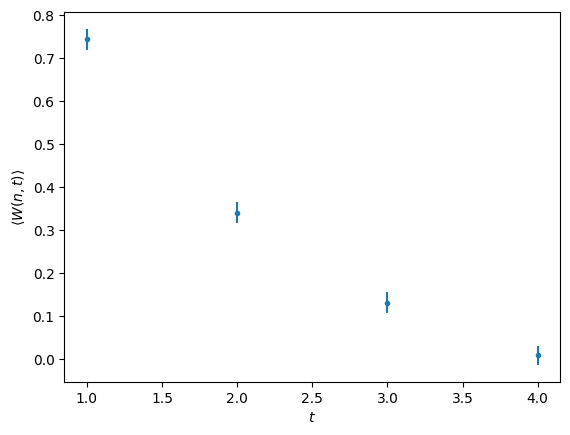

In [1123]:
plot_wilson_vs_t(3, W_data, W_err, t_values)

In [1124]:
def plot_wilson_vs_n(t_index, W_data, W_err, n_values):

    plt.errorbar(n_values, W_data[:, t_index], yerr=W_err[:, t_index],fmt='.')

    plt.xlabel(r"$n$")
    plt.ylabel(r"$\langle W(n,t) \rangle$")
    plt.show()

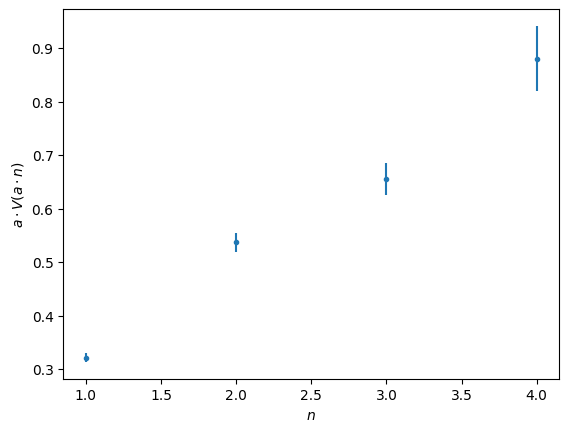

In [1125]:
plt.errorbar(n_values, aV, aV_err, fmt = '.')

plt.xlabel(r"$n$")
plt.ylabel(r"$a\cdot V(a\cdot n)$")
plt.show()

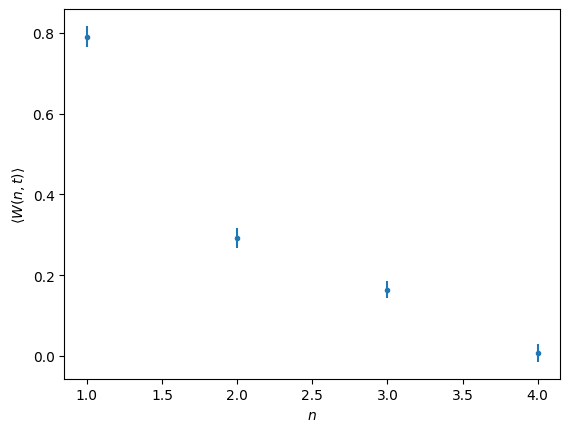

In [1126]:
plot_wilson_vs_n(t_index=3
                 , W_data=(W_data), W_err=W_err, n_values=n_values)

### Get Sommer parameter and lattice spacing

In [1127]:
r0_a = np.sqrt((1.65 + B) / (sigmaa2))

r0_a_err = np.sqrt(
    (B_err / (2 * sigmaa2 * r0_a))**2 +
    ((r0_a * sigmaa2_err) / (2 * sigmaa2))**2
)

print('r0_a', r0_a)
print('r0_a_err', r0_a_err)


r0_phys = 0.5 #fm
a = r0_phys / r0_a
a_err = a * (r0_a_err / r0_a)

print('a',a)
print('a_err',a_err)

# literature value to compare for beta in [5.7,6.92] -> dependence on renormalization group 
def a_lit(r0, beta):

    e = np.exp(-1.6804 - 1.7331 * (beta - 6) + 0.7849 * (beta - 6)**2 - 0.4428 * (beta - 6)**3)

    return r0 * e

beta = 6.85
a_exp = a_lit(r0_phys, beta)
print('beta', beta)
print('a_exp', a_exp)

r0_a 3.422543489972489
r0_a_err 0.5352134095966602
a 0.14609018160468112
a_err 0.02284541436341695
beta 6.85
a_exp 0.028680825499451355


### Get the potential $V(r)$

In [1128]:
sigma = sigmaa2 / a**2 * (1 / 5.068)#GeV / fm
A = Aa / a * 1 / 5.068#GeV

A_err = np.sqrt((Aa_err / a)**2 + (Aa * a_err / a**2)**2)* 1 / 5.068
sigma_err = np.sqrt((sigmaa2_err / a)**2 + (2*sigmaa2 * a_err / a**3)**2)* (1 / 5.068)#


print('A',A)
print('A_err',A_err)
print('B',B)
print('B_err',B_err)
print('sigma',sigma)
print('sigma_err',sigma_err)

def V_phys(r):

    return A + B / r + sigma*r

def V_phys_err(r):

    return np.sqrt(A_err**2 + (B_err / r)**2 + (r * sigma_err)**2)

B_lit = - 4/3* 0.6
#print(B_lit)

A 0.48296198887917496
A_err 0.20413495772280402
B -0.16270786711393048
B_err 0.1041564527435336
sigma 1.1738690867293364
sigma_err 0.3708392697920322


In [1129]:
r_val = a * n_values
V_val = V_phys(r_val)
V_val_err = V_phys_err(r_val)

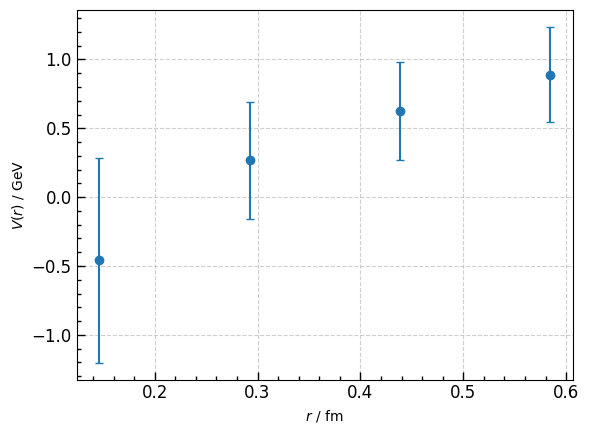

In [1130]:
plt.errorbar(r_val, V_val, yerr=V_val_err, fmt='o', capsize=3)
plt.xlabel(r"$r$ / fm")
plt.ylabel(r"$V(r)$ / GeV")
plt.grid(True, linestyle='--', alpha=0.6)
plt.minorticks_on()
plt.tick_params(axis='both', which='major', direction='in', length=6, width=1)
plt.tick_params(axis='both', which='minor', direction='in', length=3, width=1)


plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

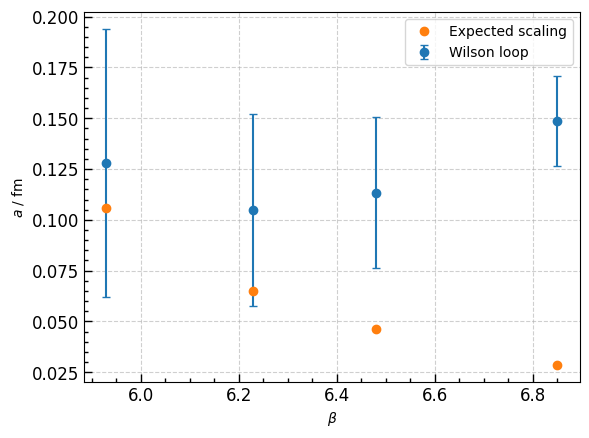

In [1131]:
beta = np.array([5.93, 6.23, 6.48, 6.85])

a = np.array([0.128, 0.10473180094323488, 0.11338950359346325, 0.14851720764263154])
a_err = np.array([0.066, 0.04729271994269493, 0.03703349363145528, 0.02201994429472431])
a_exp = np.array([0.106, 0.06482742640609973, 0.046255987767519206, 0.028680825499451355])

plt.figure()

plt.errorbar(beta, a, yerr=a_err, fmt='o', capsize=3,label='Wilson loop')

plt.plot(beta, a_exp, 'o', label='Expected scaling')

plt.xlabel(r'$\beta$')
plt.ylabel(r'$a$ / fm')

plt.legend()

plt.grid(True, linestyle='--', alpha=0.6)
plt.minorticks_on()
plt.tick_params(axis='both', which='major', direction='in', length=6, width=1)
plt.tick_params(axis='both', which='minor', direction='in', length=3, width=1)


plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()